In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


df = pd.read_csv("data/processed_data_last_3.csv", parse_dates=["date"]).copy()

features = [
'diff_elo',
'diff_avg_goals_for', 
'diff_avg_goals_against',
'diff_avg_points', 
'diff_ranking',
'diff_fifa_points',
'ranking_local',
'ranking_away',
'change_local',
'change_away'
]

df_training = df[df["date"] < "2026-05-01"]
df_training = df_training.dropna(subset=features)

df_train = df_training[(df_training["date"] < "2023-06-01") ].copy()
X_train = df_train[features]
y_train = df_train["result"]
df_test = df_training[(df_training["date"] >= "2023-06-01") ].copy()
X_test = df_test[features]
y_test = df_test["result"]
y_test

model = HistGradientBoostingClassifier(
    max_iter=100,  
    learning_rate=0.03,  # pasos cortos
    max_depth=3,  # limitamos la profundidad
    min_samples_leaf=70,  # Exigimos que al menos 30 partidos cumplan una regla para darla por válida
    random_state=45,
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)


precission = accuracy_score(y_test, predictions)

print(f"Precission: {precission * 100:.2f}%")
print("\nFor every result (1=Local, 0=Draw, 2=Away):")
print(classification_report(y_test, predictions))



Precission: 59.95%

For every result (1=Local, 0=Draw, 2=Away):
              precision    recall  f1-score   support

           0       0.33      0.00      0.00       624
           1       0.60      0.89      0.72      1169
           2       0.59      0.64      0.62       759

    accuracy                           0.60      2552
   macro avg       0.51      0.51      0.45      2552
weighted avg       0.53      0.60      0.51      2552



Gradient Boosting : 59.84%

 Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.32      0.20      0.25       624
           1       0.64      0.84      0.73      1169
           2       0.66      0.55      0.60       759

    accuracy                           0.60      2552
   macro avg       0.54      0.53      0.53      2552
weighted avg       0.57      0.60      0.57      2552



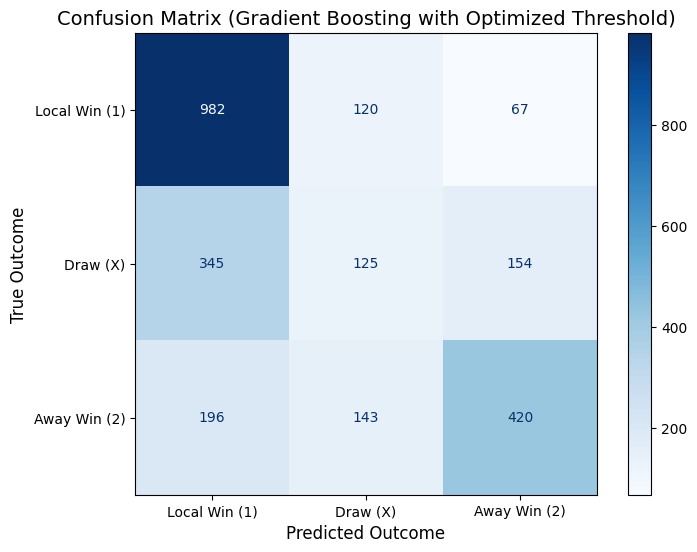

In [22]:

probs = model.predict_proba(X_test)

optimized_predictions = []
treshold = 0.15

for p in probs:
    prob_draw, prob_local, prob_away = p[0], p[1], p[2]
    

    diff_local_away = abs(prob_local - prob_away)
    
    if diff_local_away < treshold:  
        optimized_predictions.append(0) 
    else:
        
        if prob_local > prob_away:
            optimized_predictions.append(1)
        else:
            optimized_predictions.append(2)

optimized_predictions = np.array(optimized_predictions)


print(f"Gradient Boosting : {accuracy_score(y_test, optimized_predictions) * 100:.2f}%")
print("\n Report with Optimized Threshold:")
print(classification_report(y_test, optimized_predictions))


cm = confusion_matrix(y_test, optimized_predictions, labels=[1, 0, 2])

# Dibujamos la matriz con el estilo visual limpio de tu proyecto
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Local Win (1)', 'Draw (X)', 'Away Win (2)']
)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix (Gradient Boosting with Optimized Threshold)', fontsize=14)
plt.xlabel('Predicted Outcome', fontsize=12)
plt.ylabel('True Outcome', fontsize=12)
plt.show()

In [23]:
df_train_final = df[df["date"] < "2026-06-01"]
X_train_final = df_train[features]
y_train_final = df_train["result"]

#ultimo entrenamiento con todos los datos disponibles
model.fit(X_train_final, y_train_final)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",3
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",70
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [24]:
def optimice_draw(probs, threshold=0.15):

    optimized_predictions = []
    
    for p in probs:
        prob_draw, prob_local, prob_away = p[0], p[1], p[2]
        diff_local_away = abs(prob_local - prob_away)
        
        if diff_local_away < threshold:  
            optimized_predictions.append(0) # Empate por fuerzas igualadas
        else:
            if prob_local > prob_away:
                optimized_predictions.append(1) # Gana Local
            else:
                optimized_predictions.append(2) # Gana Visitante
                
    return np.array(optimized_predictions)

In [25]:
def simulate_match(team_A, team_B, n_steps=10000):
    """
    Busca los datos de dos equipos, aplica simetría y corre 10.000 simulaciones de Montecarlo.
    """
    row_A = df[(df['home_team'] == team_A) | (df['away_team'] == team_A)]
    row_B = df[(df['home_team'] == team_B) | (df['away_team'] == team_B)]
    
    if row_A.empty or row_B.empty:
        raise ValueError(f"Make sure tha names of ({team_A} or {team_B}) are in the dataset.")
        
    row_A = row_A.iloc[-1]
    row_B = row_B.iloc[-1]

    def extract_metrics(row, team):
        if row['home_team'] == team:
            return row['elo_local'], row['avg_goals_for_local'], row['avg_goals_against_local'], row['avg_points_local'], row['ranking_local'],row['fifa_points_local'], row['change_local']
        else:
            return row['elo_away'], row['avg_goals_for_away'], row['avg_goals_against_away'], row['avg_points_away'], row['ranking_away'], row['fifa_points_away'], row['change_away']

   
    elo_A, g_f_A, g_a_A, pts_A, r_A, f_pts_A, ch_A = extract_metrics(row_A, team_A)
    elo_B, g_f_B, g_a_B, pts_B, r_B, f_pts_B, ch_B = extract_metrics(row_B, team_B)

    
    data_1 = {
        'diff_elo': elo_A - elo_B, 'diff_avg_goals_for': g_f_A - g_f_B, 'diff_avg_goals_against': g_a_A - g_a_B,
        'diff_avg_points': pts_A - pts_B, 'diff_ranking': r_A - r_B, 'diff_fifa_points': f_pts_A - f_pts_B,
        'ranking_local': r_A, 'ranking_away': r_B, 'change_local': ch_A, 'change_away': ch_B
    }
    data_2 = {
        'diff_elo': elo_B - elo_A, 'diff_avg_goals_for': g_f_B - g_f_A, 'diff_avg_goals_against': g_a_B - g_a_A,
        'diff_avg_points': pts_B - pts_A, 'diff_ranking': r_B - r_A, 'diff_fifa_points': f_pts_B - f_pts_A,
        'ranking_local': r_B, 'ranking_away': r_A, 'change_local': ch_B, 'change_away': ch_A
    }

    # Convertimos a DataFrame respetando el orden exacto de tus features
    df_scenario_1 = pd.DataFrame([data_1])[features]
    df_scenario_2 = pd.DataFrame([data_2])[features]

    # Predicciones probabilísticas del modelo entrenado
    prob_1 = model.predict_proba(df_scenario_1)[0]
    prob_2 = model.predict_proba(df_scenario_2)[0]

    # Promediamos las probabilidades cruzadas para eliminar el sesgo administrativo
    # prob[0]=Empate, prob[1]=Gana Local, prob[2]=Gana Visitante
    p_draw = (prob_1[0] + prob_2[0]) / 2
    p_A = (prob_1[1] + prob_2[2]) / 2
    p_B = (prob_1[2] + prob_2[1]) / 2
    
    total_p = p_draw + p_A + p_B
    p_draw, p_A, p_B = p_draw / total_p, p_A / total_p, p_B / total_p

    resultados_simulados = np.random.choice(
        ['Draw', f'{team_A} Wins', f'{team_B} Wins'], 
        size=n_steps, 
        p=[p_draw, p_A, p_B]
    )

    unique, count = np.unique(resultados_simulados, return_counts=True)
    frequencies = dict(zip(unique, count))

    print(f"MONTECARLO ({n_steps} iterations) | {team_A} vs {team_B}")
    for res, times in frequencies.items():
        percentage = (times / n_steps) * 100
        print(f"{res}: {percentage:.2f}% ({times} times)")
        
    return frequencies

In [26]:
match = simulate_match("Spain", "Uruguay", n_steps=10000)

MONTECARLO (10000 iterations) | Spain vs Uruguay
Draw: 26.34% (2634 times)
Spain Wins: 54.40% (5440 times)
Uruguay Wins: 19.26% (1926 times)
